[21:54:40] Device: cuda | dtype: torch.float64
[21:54:43]   epoch 0100/2000 | -ELBO=1.4300 | ℓ=0.596 σ²=0.552 noise=0.2771 | mem=17MB
[21:54:44]   epoch 0200/2000 | -ELBO=1.1785 | ℓ=0.501 σ²=0.528 noise=0.3246 | mem=17MB
[21:54:45]   epoch 0300/2000 | -ELBO=1.1530 | ℓ=0.455 σ²=0.519 noise=0.3592 | mem=17MB
[21:54:47]   epoch 0400/2000 | -ELBO=1.0479 | ℓ=0.413 σ²=0.510 noise=0.3835 | mem=17MB
[21:54:49]   epoch 0500/2000 | -ELBO=1.0461 | ℓ=0.381 σ²=0.501 noise=0.3945 | mem=17MB
[21:54:51]   epoch 0600/2000 | -ELBO=0.9618 | ℓ=0.283 σ²=0.492 noise=0.3951 | mem=17MB
[21:54:52]   epoch 0700/2000 | -ELBO=0.8292 | ℓ=0.238 σ²=0.487 noise=0.3724 | mem=17MB
[21:54:53]   epoch 0800/2000 | -ELBO=0.7253 | ℓ=0.215 σ²=0.487 noise=0.3254 | mem=17MB
[21:54:55]   epoch 0900/2000 | -ELBO=0.6041 | ℓ=0.197 σ²=0.486 noise=0.2689 | mem=17MB
[21:54:57]   epoch 1000/2000 | -ELBO=0.4860 | ℓ=0.185 σ²=0.486 noise=0.2089 | mem=17MB
[21:54:59]   epoch 1100/2000 | -ELBO=0.1410 | ℓ=0.169 σ²=0.464 noise=0.1463 | mem=1

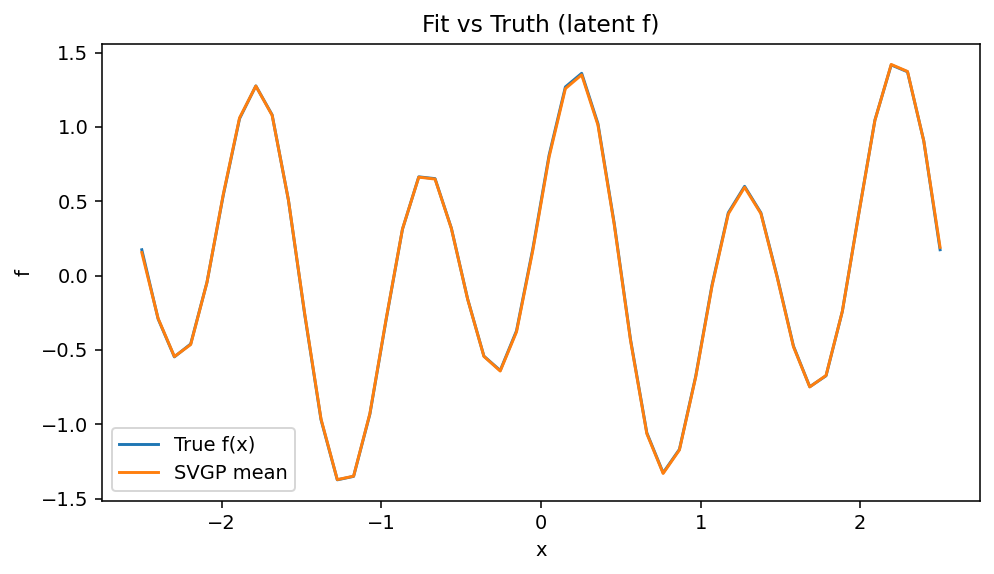

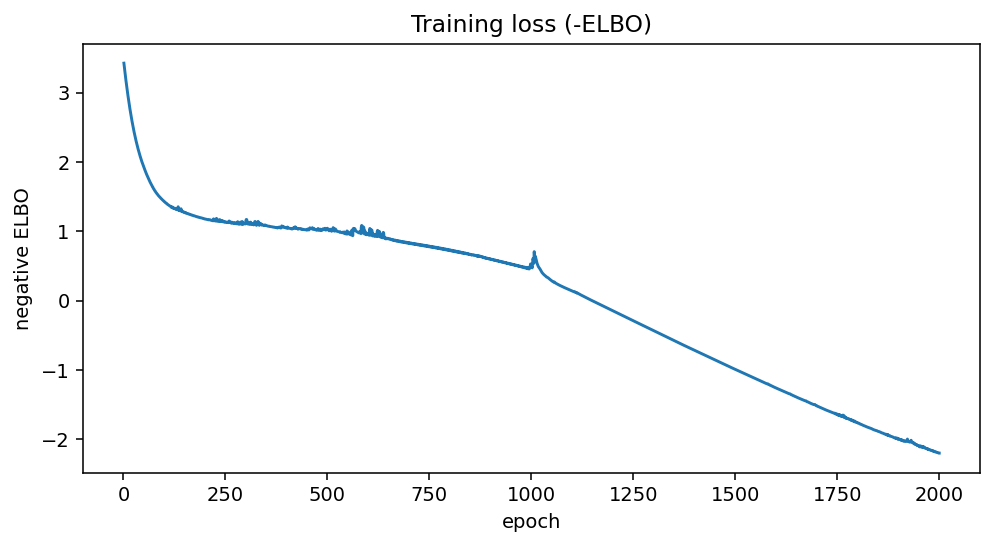

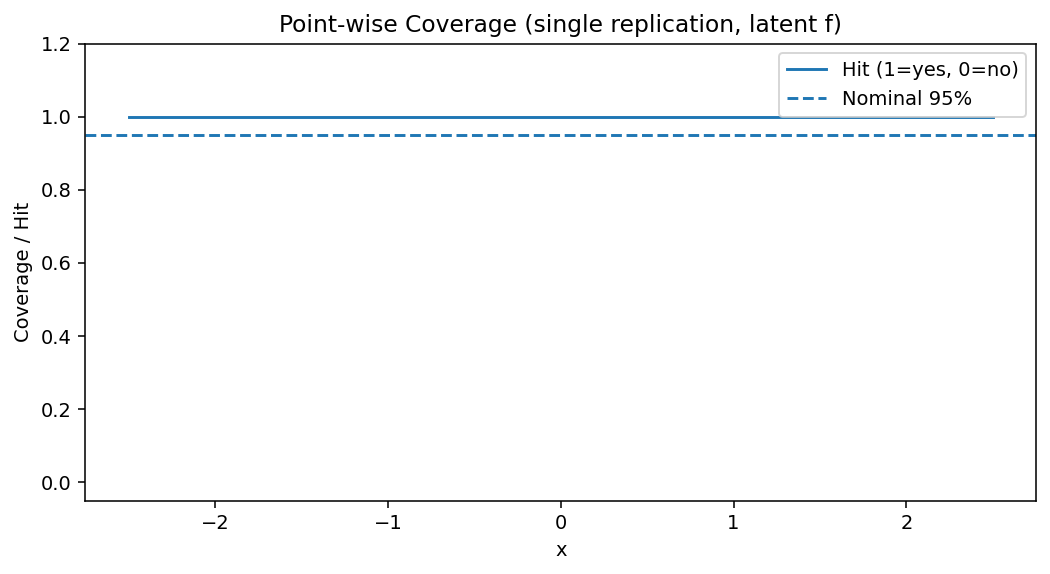

[21:55:16] RMSE (latent f mean vs truth): 0.006238
[21:55:16] Saved: fit_vs_truth.png | elbo_curve.png | coverage_curve_single.png


In [1]:
# svgp_ciq_regression_single.py  (latent-f only; 1 replication; 3 plots)
import math, os, time
from contextlib import ExitStack
from dataclasses import dataclass

import torch, gpytorch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 140

# ---------------- Logging ----------------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)
def gpu_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e6
    return 0.0

# ---------------- Utilities ----------------
def has_setting(name: str) -> bool: return hasattr(gpytorch.settings, name)

def ciq_context():
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)

# ---------------- Config ----------------
@dataclass
class CFG:
    # sizes (as requested)
    n_train: int = 500
    n_test: int  = 50

    # single replication
    R: int = 1
    train_low: float = -2.5
    train_high: float =  2.5
    test_low: float  = -2.5
    test_high: float =  2.5

    # training
    use_fp64: bool = True
    use_ciq: bool = False
    epochs: int = 2000
    batch_size: int = 500
    inducing_points: int = 32
    lr_adam: float = 5e-3
    jitter: float = 1e-2
    seed: int = 13

    # reporting
    nominal_p: float = 0.95
    save_dir: str = "."

# ---------------- Model ----------------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points: torch.Tensor):
        M = inducing_points.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points, q_dist, learn_inducing_locations=True
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------- Train once (returns ELBO history) ----------------
def train_svgp_once(x_train_n, y_train, M, lr, epochs, jitter, batch_size, device, dtype):
    perm = torch.randperm(x_train_n.size(0), device=device)
    Z = x_train_n[perm[:M]].clone().contiguous()

    model = SVGPModel(Z).to(device=device, dtype=dtype)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device, dtype=dtype)

    with torch.no_grad():
        model.covar_module.base_kernel.lengthscale.fill_(1.0)
        model.covar_module.outputscale.fill_(1.0)
        likelihood.noise = torch.as_tensor(0.20, dtype=dtype, device=device)

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=x_train_n.size(0))
    opt = torch.optim.Adam([
        {'params': model.variational_parameters()},
        {'params': model.hyperparameters()},
        {'params': likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_n, y_train),
                        batch_size=batch_size, shuffle=True, drop_last=True)

    model.train(); likelihood.train()
    elbo_hist = []

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total = 0.0; n_batches = 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                torch.nn.utils.clip_grad_norm_(likelihood.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1
            elbo_hist.append(total / max(1, n_batches))
            if ep % 100 == 0:
                with torch.no_grad():
                    ls = float(model.covar_module.base_kernel.lengthscale.mean())
                    os = float(model.covar_module.outputscale)
                    nz = float(likelihood.noise)
                log(f"  epoch {ep:04d}/{epochs} | -ELBO={elbo_hist[-1]:.4f} | ℓ={ls:.3f} σ²={os:.3f} noise={nz:.4f} | mem={gpu_mem_mb():.0f}MB")

    model.eval(); likelihood.eval()
    return model, likelihood, elbo_hist

# ---------------- Main ----------------
def main():
    cfg = CFG()

    # device/dtype
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(cfg.seed)

    log(f"Device: {device} | dtype: {torch.get_default_dtype()}")

    # fixed test grid
    x_test = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test, device=device).unsqueeze(1)
    y_true = f0(x_test).squeeze(-1)

    # single replication design
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    x_tr = make_stratified_points_1d(cfg.n_train, cfg.train_low, cfg.train_high,
                                     generator=gen, device=device, dtype=torch.get_default_dtype())
    y_tr = f0(x_tr).squeeze(-1)

    # per-rep standardization
    x_mean, x_std = x_tr.mean(0, keepdim=True), x_tr.std(0, keepdim=True).clamp_min(1e-6)
    x_tr_n = (x_tr - x_mean) / x_std
    x_te_n = (x_test - x_mean) / x_std

    # train
    ctx = ciq_context() if cfg.use_ciq else ExitStack()
    with ctx:
        model, likelihood, elbo_hist = train_svgp_once(
            x_train_n=x_tr_n, y_train=y_tr, M=cfg.inducing_points,
            lr=cfg.lr_adam, epochs=cfg.epochs, jitter=cfg.jitter,
            batch_size=cfg.batch_size, device=device, dtype=torch.get_default_dtype()
        )

        # predict latent f on test grid
        with torch.no_grad():
            pred_f = model(x_te_n)
            mu, sd = pred_f.mean, pred_f.stddev.clamp_min(1e-12)

    # ---------- Plots ----------
    os.makedirs(cfg.save_dir, exist_ok=True)
    x_cpu = x_test.squeeze(-1).cpu().numpy()

    # 1) Fit vs Truth
    plt.figure(figsize=(7.2, 4.2))
    plt.plot(x_cpu, y_true.cpu().numpy(), label="True f(x)")
    plt.plot(x_cpu, mu.cpu().numpy(), label="SVGP mean")
    plt.xlabel("x"); plt.ylabel("f"); plt.title("Fit vs Truth (latent f)")
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "fit_vs_truth.png"), dpi=160)
    plt.show()

    # 2) ELBO curve
    plt.figure(figsize=(7.2, 4.0))
    plt.plot(range(1, len(elbo_hist)+1), elbo_hist)
    plt.xlabel("epoch"); plt.ylabel("negative ELBO")
    plt.title("Training loss (-ELBO)")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "elbo_curve.png"), dpi=160)
    plt.show()

    # 3) Coverage plot (R=1 -> 单条曲线)
    z = torch.distributions.Normal(0., 1.)
    z975 = z.icdf(torch.tensor([(1 + CFG.nominal_p)/2], device=device, dtype=torch.get_default_dtype())).item()
    lower, upper = mu - z975*sd, mu + z975*sd
    hits = ((y_true >= lower) & (y_true <= upper)).to(torch.float64).cpu().numpy()

    plt.figure(figsize=(7.6, 4.2))
    plt.plot(x_cpu, hits, drawstyle="steps-mid", label="Hit (1=yes, 0=no)")
    plt.axhline(cfg.nominal_p, linestyle="--", label=f"Nominal {int(cfg.nominal_p*100)}%")
    plt.ylim(-0.05, 1.2)
    plt.xlabel("x"); plt.ylabel("Coverage / Hit")
    plt.title("Point-wise Coverage (single replication, latent f)")
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "coverage_curve_single.png"), dpi=160)
    plt.show()

    # simple metrics
    rmse = torch.sqrt(torch.mean((mu - y_true)**2)).item()
    log(f"RMSE (latent f mean vs truth): {rmse:.6f}")
    log("Saved: fit_vs_truth.png | elbo_curve.png | coverage_curve_single.png")

if __name__ == "__main__":
    main()
